### LIBRARY IMPORTS

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import copy
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

if os.getcwd().endswith('notebooks'):
    os.chdir('..')

from src import *
from src.data_manager import DataManager
from src.processor import Processor
from src.nn_regressor import NNRegressor
from src.gb_classifier import GBClassifier

warnings.simplefilter(action='ignore', category=FutureWarning)

### CONFIGURATION

In [3]:
data_manager = DataManager()

datasets_config, modeling_config = data_manager.load_config()

active_dataset = modeling_config["main"]["active_dataset"]
active_dataset_config = datasets_config[active_dataset]
target = active_dataset_config["target"]

problem_type = active_dataset_config["problem_type"]

gradient_boosting_config = modeling_config["gradient_boosting"]

weak_learner_key = gradient_boosting_config["weak_learner_key"]
weak_learner_config = modeling_config[weak_learner_key]

processor = Processor(**active_dataset_config)

raw_train, raw_test = data_manager.load_raw_data()
raw_train = processor.cut_data(raw_train)

### STRATIFIED CROSS-VALIDATION

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def my_cross_validation(model, data, target, skf, processor):
    log_loss_scores = []
    accuracy_scores = []

    num_classes = len(np.unique(data[target]))
    oof_preds = np.zeros((len(data), num_classes), dtype=float)

    for train_idx, valid_idx in skf.split(data, data[target]):
        train_df = raw_train.iloc[train_idx]
        valid_df = raw_train.iloc[valid_idx]

        train_proc = processor.fit_transform(train_df)
        valid_proc = processor.transform(valid_df)

        X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
        X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

        model.fit(X_train, y_train)

        prob_preds = model.predict_proba(X_valid)
        class_preds = np.argmax(prob_preds, axis=1)
        
        oof_preds[valid_idx] = prob_preds

        fold_log_loss = log_loss(y_valid, prob_preds, labels=np.unique(y_train))
        fold_accuracy = accuracy_score(y_valid, class_preds)
        
        log_loss_scores.append(fold_log_loss)
        accuracy_scores.append(fold_accuracy)
    
    return log_loss_scores, accuracy_scores, oof_preds

### LOGISTIC REGRESSION

In [5]:
%%time

logistic = LogisticRegression(C=1.0, random_state=42)
logistic_log_loss_scores, logistic_accuracy_scores, logistic_oof_preds = my_cross_validation(logistic, raw_train, target, skf, processor)

CPU times: total: 2.19 s
Wall time: 1.39 s


In [6]:
print("Logistic regression log loss:", logistic_log_loss_scores)
print("Logistic regression accuracy:", logistic_accuracy_scores)

Logistic regression log loss: [0.2697083374586127, 0.2670589976179254, 0.2758899059085812, 0.27167092830671735, 0.2791858772055752]
Logistic regression accuracy: [0.8886, 0.89185, 0.88595, 0.88725, 0.88215]


### DECISION TREE

In [7]:
%%time

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_log_loss_scores, dt_accuracy_scores, dt_oof_preds = my_cross_validation(dt, raw_train, target, skf, processor)

CPU times: total: 1.41 s
Wall time: 1.41 s


In [8]:
print("Decision tree log loss:", dt_log_loss_scores)
print("Decision tree accuracy:", dt_accuracy_scores)

Decision tree log loss: [0.32993688135856475, 0.31909432879316635, 0.32635251177055696, 0.3247999491190048, 0.3335430533095905]
Decision tree accuracy: [0.85845, 0.86505, 0.8651, 0.86155, 0.85695]


### RANDOM FOREST

In [9]:
%%time

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_log_loss_scores, rf_accuracy_scores, rf_oof_preds = my_cross_validation(rf, raw_train, target, skf, processor)

CPU times: total: 13.6 s
Wall time: 13.6 s


In [10]:
print("Random forest log loss:", rf_log_loss_scores)
print("Random forest accuracy:", rf_accuracy_scores)

Random forest log loss: [0.32126289442411876, 0.31435168984356093, 0.3192231125932434, 0.31609176277492995, 0.32313417347027207]
Random forest accuracy: [0.872, 0.87545, 0.87315, 0.8747, 0.8654]


### NEURAL NETWORK

In [11]:
class MLP(NNRegressor):
    def __init__(self, **hyperparameters):
        super().__init__(**hyperparameters)

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_valid: np.ndarray,
        y_valid: np.ndarray, 
        patience: int = 10
    ) -> None:
        input_size = X_train.shape[1]
        
        unique_classes = np.unique(y_train)
        output_size = len(unique_classes)
        
        self._get_network(input_size, output_size)
        
        train_loader = self._prepare_loader(X_train, y_train)
        
        X_valid_t = torch.from_numpy(X_valid).to(torch.float32).to(self.device)
        y_valid_t = torch.from_numpy(y_valid).to(torch.long).to(self.device).squeeze()

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.parameters(), lr=self.learning_rate)
        
        best_loss = float('inf')
        best_model = None
        early_stop_count = 0

        for epoch in range(self.epochs):
            self.train()
            train_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                
                optimizer.zero_grad()
                preds = self(batch_X)
                loss = criterion(preds, batch_y.to(torch.long).to(self.device).squeeze())
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            self.eval()
            with torch.no_grad():
                val_preds = self(X_valid_t)
                val_loss = criterion(val_preds, y_valid_t).item()

                pred_labels = val_preds.argmax(dim=1)
                val_acc = (pred_labels == y_valid_t).float().mean().item()

            if (epoch + 1) % 10 == 0:
                print(f"Epoch: {epoch + 1} | Validation log loss: {val_loss:.4f} | Validation accuracy {val_acc:.4f}")

            if val_loss < best_loss:
                best_loss = val_loss
                best_model = copy.deepcopy(self.state_dict())
                early_stop_count = 0
            else:
                early_stop_count += 1

            if early_stop_count >= patience:
                break
                
        if best_model:
            self.load_state_dict(best_model)
    
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X_t = torch.from_numpy(X).to(torch.float32).to(self.device)
        self.eval()
        with torch.no_grad():
            logits = self.forward(X_t)
            predictions = torch.softmax(logits, dim=1)
        
        return predictions.cpu().numpy()

In [12]:
%%time

mlp = MLP(epochs=100, learning_rate=0.001, hidden_size=[16, 8], batch_size=1024)

mlp_log_loss_scores = []
mlp_accuracy_scores = []
num_classes = len(np.unique(raw_train[target]))
mlp_oof_preds = np.zeros((len(raw_train), num_classes), dtype=float)

for train_idx, valid_idx in skf.split(raw_train, raw_train[target]):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    mlp.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    prob_preds = mlp.predict_proba(X_valid.values)
    class_preds = np.argmax(prob_preds, axis=1)
    
    mlp_oof_preds[valid_idx] = prob_preds

    fold_log_loss = log_loss(y_valid, prob_preds, labels=np.unique(y_train))
    fold_accuracy = accuracy_score(y_valid, class_preds)
        
    mlp_log_loss_scores.append(fold_log_loss)
    mlp_accuracy_scores.append(fold_accuracy)

    print('-' * 50)

Epoch: 10 | Validation log loss: 0.2704 | Validation accuracy 0.8887
Epoch: 20 | Validation log loss: 0.2697 | Validation accuracy 0.8889
Epoch: 30 | Validation log loss: 0.2701 | Validation accuracy 0.8887
--------------------------------------------------
Epoch: 10 | Validation log loss: 0.2692 | Validation accuracy 0.8899
Epoch: 20 | Validation log loss: 0.2676 | Validation accuracy 0.8911
Epoch: 30 | Validation log loss: 0.2674 | Validation accuracy 0.8905
--------------------------------------------------
Epoch: 10 | Validation log loss: 0.2772 | Validation accuracy 0.8863
Epoch: 20 | Validation log loss: 0.2754 | Validation accuracy 0.8865
Epoch: 30 | Validation log loss: 0.2757 | Validation accuracy 0.8871
--------------------------------------------------
Epoch: 10 | Validation log loss: 0.2719 | Validation accuracy 0.8877
Epoch: 20 | Validation log loss: 0.2714 | Validation accuracy 0.8877
Epoch: 30 | Validation log loss: 0.2718 | Validation accuracy 0.8877
-------------------

In [13]:
print("Neural network log loss:", mlp_log_loss_scores)
print("Neural network accuracy:", mlp_accuracy_scores)

Neural network log loss: [0.26904555023423254, 0.2671455389617693, 0.27534354247254106, 0.27132336182763767, 0.2787435265055358]
Neural network accuracy: [0.88925, 0.89105, 0.88595, 0.8876, 0.88265]


### GRADIENT BOOSTING (DTs)

In [14]:
%%time

gb_log_loss_scores = []
gb_accuracy_scores = []
num_classes = len(np.unique(raw_train[target]))
gb_oof_preds = np.zeros((len(raw_train), num_classes), dtype=float)

for train_idx, valid_idx in skf.split(raw_train, raw_train[target]):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    gb = GBClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        early_stopping_rounds=10,
        weak_learner_key="decision_tree",
        weak_learner_config={"max_depth": 5, "random_state": 42}
    )
    
    gb.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    prob_preds = gb.predict_proba(X_valid.values)
    class_preds = np.argmax(prob_preds, axis=1)
    
    gb_oof_preds[valid_idx] = prob_preds

    fold_log_loss = log_loss(y_valid, prob_preds, labels=np.unique(y_train))
    fold_accuracy = accuracy_score(y_valid, class_preds)
    
    gb_log_loss_scores.append(fold_log_loss)
    gb_accuracy_scores.append(fold_accuracy)
    
    print('-' * 50)

2026-04-24 15:22:09,955 - INFO - Iteration: 10 | Validation Log Loss: 0.520778 | Validation Accuracy: 0.866650
2026-04-24 15:22:11,235 - INFO - Iteration: 20 | Validation Log Loss: 0.436254 | Validation Accuracy: 0.874500
2026-04-24 15:22:12,508 - INFO - Iteration: 30 | Validation Log Loss: 0.388909 | Validation Accuracy: 0.877050
2026-04-24 15:22:13,806 - INFO - Iteration: 40 | Validation Log Loss: 0.359643 | Validation Accuracy: 0.878250
2026-04-24 15:22:15,080 - INFO - Iteration: 50 | Validation Log Loss: 0.340103 | Validation Accuracy: 0.882000
2026-04-24 15:22:16,380 - INFO - Iteration: 60 | Validation Log Loss: 0.326284 | Validation Accuracy: 0.882400
2026-04-24 15:22:17,640 - INFO - Iteration: 70 | Validation Log Loss: 0.316066 | Validation Accuracy: 0.883850
2026-04-24 15:22:18,940 - INFO - Iteration: 80 | Validation Log Loss: 0.308346 | Validation Accuracy: 0.883900
2026-04-24 15:22:20,247 - INFO - Iteration: 90 | Validation Log Loss: 0.302207 | Validation Accuracy: 0.884250
2

--------------------------------------------------


2026-04-24 15:23:45,870 - INFO - Iteration: 10 | Validation Log Loss: 0.521170 | Validation Accuracy: 0.871050
2026-04-24 15:23:47,161 - INFO - Iteration: 20 | Validation Log Loss: 0.434944 | Validation Accuracy: 0.880700
2026-04-24 15:23:48,465 - INFO - Iteration: 30 | Validation Log Loss: 0.385796 | Validation Accuracy: 0.881750
2026-04-24 15:23:49,731 - INFO - Iteration: 40 | Validation Log Loss: 0.355234 | Validation Accuracy: 0.884500
2026-04-24 15:23:50,995 - INFO - Iteration: 50 | Validation Log Loss: 0.335380 | Validation Accuracy: 0.885500
2026-04-24 15:23:52,266 - INFO - Iteration: 60 | Validation Log Loss: 0.321468 | Validation Accuracy: 0.887000
2026-04-24 15:23:53,584 - INFO - Iteration: 70 | Validation Log Loss: 0.311309 | Validation Accuracy: 0.887650
2026-04-24 15:23:54,870 - INFO - Iteration: 80 | Validation Log Loss: 0.303745 | Validation Accuracy: 0.888300
2026-04-24 15:23:56,158 - INFO - Iteration: 90 | Validation Log Loss: 0.297819 | Validation Accuracy: 0.888750
2

--------------------------------------------------


2026-04-24 15:25:30,708 - INFO - Iteration: 10 | Validation Log Loss: 0.522215 | Validation Accuracy: 0.870200
2026-04-24 15:25:31,934 - INFO - Iteration: 20 | Validation Log Loss: 0.436517 | Validation Accuracy: 0.877150
2026-04-24 15:25:33,217 - INFO - Iteration: 30 | Validation Log Loss: 0.388707 | Validation Accuracy: 0.880000
2026-04-24 15:25:34,465 - INFO - Iteration: 40 | Validation Log Loss: 0.359212 | Validation Accuracy: 0.881550
2026-04-24 15:25:35,683 - INFO - Iteration: 50 | Validation Log Loss: 0.339943 | Validation Accuracy: 0.882400
2026-04-24 15:25:36,914 - INFO - Iteration: 60 | Validation Log Loss: 0.326623 | Validation Accuracy: 0.882500
2026-04-24 15:25:38,153 - INFO - Iteration: 70 | Validation Log Loss: 0.316825 | Validation Accuracy: 0.883900
2026-04-24 15:25:39,368 - INFO - Iteration: 80 | Validation Log Loss: 0.309546 | Validation Accuracy: 0.884000
2026-04-24 15:25:40,596 - INFO - Iteration: 90 | Validation Log Loss: 0.303752 | Validation Accuracy: 0.885250
2

--------------------------------------------------


2026-04-24 15:26:45,596 - INFO - Iteration: 10 | Validation Log Loss: 0.519115 | Validation Accuracy: 0.870050
2026-04-24 15:26:46,835 - INFO - Iteration: 20 | Validation Log Loss: 0.434186 | Validation Accuracy: 0.876800
2026-04-24 15:26:48,061 - INFO - Iteration: 30 | Validation Log Loss: 0.386537 | Validation Accuracy: 0.880550
2026-04-24 15:26:49,240 - INFO - Iteration: 40 | Validation Log Loss: 0.357264 | Validation Accuracy: 0.881250
2026-04-24 15:26:50,510 - INFO - Iteration: 50 | Validation Log Loss: 0.337594 | Validation Accuracy: 0.881800
2026-04-24 15:26:51,736 - INFO - Iteration: 60 | Validation Log Loss: 0.324100 | Validation Accuracy: 0.883250
2026-04-24 15:26:52,945 - INFO - Iteration: 70 | Validation Log Loss: 0.314263 | Validation Accuracy: 0.884150
2026-04-24 15:26:54,227 - INFO - Iteration: 80 | Validation Log Loss: 0.306730 | Validation Accuracy: 0.884650
2026-04-24 15:26:55,435 - INFO - Iteration: 90 | Validation Log Loss: 0.300912 | Validation Accuracy: 0.884850
2

--------------------------------------------------


2026-04-24 15:28:12,908 - INFO - Iteration: 10 | Validation Log Loss: 0.523250 | Validation Accuracy: 0.868950
2026-04-24 15:28:14,080 - INFO - Iteration: 20 | Validation Log Loss: 0.438982 | Validation Accuracy: 0.873600
2026-04-24 15:28:15,301 - INFO - Iteration: 30 | Validation Log Loss: 0.391607 | Validation Accuracy: 0.874100
2026-04-24 15:28:16,502 - INFO - Iteration: 40 | Validation Log Loss: 0.362484 | Validation Accuracy: 0.874950
2026-04-24 15:28:17,756 - INFO - Iteration: 50 | Validation Log Loss: 0.343090 | Validation Accuracy: 0.878100
2026-04-24 15:28:18,975 - INFO - Iteration: 60 | Validation Log Loss: 0.329547 | Validation Accuracy: 0.879250
2026-04-24 15:28:20,157 - INFO - Iteration: 70 | Validation Log Loss: 0.319769 | Validation Accuracy: 0.880200
2026-04-24 15:28:21,379 - INFO - Iteration: 80 | Validation Log Loss: 0.312265 | Validation Accuracy: 0.881450
2026-04-24 15:28:22,618 - INFO - Iteration: 90 | Validation Log Loss: 0.306517 | Validation Accuracy: 0.881500
2

--------------------------------------------------
CPU times: total: 7min 23s
Wall time: 7min 23s


In [15]:
print("Gradient boosting (DTs) log loss:", gb_log_loss_scores)
print("Gradient boosting (DTs) accuracy:", gb_accuracy_scores)

Gradient boosting (DTs) log loss: [0.266961559196812, 0.26573227569990177, 0.27514316320662235, 0.2701646502872436, 0.2773727616923217]
Gradient boosting (DTs) accuracy: [0.89165, 0.89255, 0.8869, 0.8892, 0.88435]


### XGBOOST

In [16]:
%%time

xgb_log_loss_scores = []
xgb_accuracy_scores = []
num_classes = len(np.unique(raw_train[target]))
xgb_oof_preds = np.zeros((len(raw_train), num_classes), dtype=float)

for train_idx, valid_idx in skf.split(raw_train, raw_train[target]):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    xgb = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        early_stopping_rounds=10,
        max_depth=5,
        random_state=42
    )
    
    xgb.fit(X_train.values, y_train.values, eval_set=[(X_valid.values, y_valid.values)], verbose=False)

    prob_preds = xgb.predict_proba(X_valid.values)
    class_preds = np.argmax(prob_preds, axis=1)
    
    xgb_oof_preds[valid_idx] = prob_preds

    fold_log_loss = log_loss(y_valid, prob_preds, labels=np.unique(y_train))
    fold_accuracy = accuracy_score(y_valid, class_preds)
    
    xgb_log_loss_scores.append(fold_log_loss)
    xgb_accuracy_scores.append(fold_accuracy)

CPU times: total: 34.7 s
Wall time: 3.28 s


In [17]:
print("XGBoost log loss:", xgb_log_loss_scores)
print("XGBoost accuracy:", xgb_accuracy_scores)

XGBoost log loss: [0.26633176912856044, 0.26525105840337, 0.2731542084175374, 0.267897387058812, 0.27534309674090107]
XGBoost accuracy: [0.8908, 0.8919, 0.8865, 0.88965, 0.8846]


### GRADIENT BOOSTING (NNs)

In [20]:
%%time

nn_gb_log_loss_scores = []
nn_gb_accuracy_scores = []
num_classes = len(np.unique(raw_train[target]))
nn_gb_oof_preds = np.zeros((len(raw_train), num_classes), dtype=float)

for train_idx, valid_idx in skf.split(raw_train, raw_train[target]):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    nn_gb = GBClassifier(
        n_estimators=1000,
        learning_rate=0.5,
        subsample=1.0,
        colsample_bytree=1.0,
        reg_lambda=0.5,
        early_stopping_rounds=10,
        weak_learner_key="neural_network",
        weak_learner_config={
            "epochs": 10,
            "learning_rate": 0.001,
            "hidden_size": [16, 8],
            "batch_size": 1024
        }
    )
    
    nn_gb.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    prob_preds = nn_gb.predict_proba(X_valid.values)
    class_preds = np.argmax(prob_preds, axis=1)
    
    nn_gb_oof_preds[valid_idx] = prob_preds

    fold_log_loss = log_loss(y_valid, prob_preds, labels=np.unique(y_train))
    fold_accuracy = accuracy_score(y_valid, class_preds)
    
    nn_gb_log_loss_scores.append(fold_log_loss)
    nn_gb_accuracy_scores.append(fold_accuracy)
    
    print('-' * 50)

2026-04-24 16:48:02,051 - INFO - Iteration: 10 | Validation Log Loss: 0.289281 | Validation Accuracy: 0.888500
2026-04-24 16:49:10,931 - INFO - Iteration: 20 | Validation Log Loss: 0.276565 | Validation Accuracy: 0.888950
2026-04-24 16:50:19,783 - INFO - Iteration: 30 | Validation Log Loss: 0.273662 | Validation Accuracy: 0.888950
2026-04-24 16:51:28,294 - INFO - Iteration: 40 | Validation Log Loss: 0.272407 | Validation Accuracy: 0.889350
2026-04-24 16:52:38,260 - INFO - Iteration: 50 | Validation Log Loss: 0.271810 | Validation Accuracy: 0.889550
2026-04-24 16:53:47,579 - INFO - Iteration: 60 | Validation Log Loss: 0.271465 | Validation Accuracy: 0.889400
2026-04-24 16:54:56,441 - INFO - Iteration: 70 | Validation Log Loss: 0.271186 | Validation Accuracy: 0.889500
2026-04-24 16:56:05,469 - INFO - Iteration: 80 | Validation Log Loss: 0.271141 | Validation Accuracy: 0.889200
2026-04-24 16:57:14,707 - INFO - Iteration: 90 | Validation Log Loss: 0.271021 | Validation Accuracy: 0.889050
2

--------------------------------------------------


2026-04-24 17:02:32,009 - INFO - Iteration: 10 | Validation Log Loss: 0.285859 | Validation Accuracy: 0.890400
2026-04-24 17:03:40,633 - INFO - Iteration: 20 | Validation Log Loss: 0.273326 | Validation Accuracy: 0.890550
2026-04-24 17:04:49,188 - INFO - Iteration: 30 | Validation Log Loss: 0.270540 | Validation Accuracy: 0.890750
2026-04-24 17:05:57,869 - INFO - Iteration: 40 | Validation Log Loss: 0.269547 | Validation Accuracy: 0.890250
2026-04-24 17:07:06,248 - INFO - Iteration: 50 | Validation Log Loss: 0.269179 | Validation Accuracy: 0.890600
2026-04-24 17:08:15,217 - INFO - Iteration: 60 | Validation Log Loss: 0.268937 | Validation Accuracy: 0.890350
2026-04-24 17:09:23,775 - INFO - Iteration: 70 | Validation Log Loss: 0.268839 | Validation Accuracy: 0.890300
2026-04-24 17:10:32,478 - INFO - Iteration: 80 | Validation Log Loss: 0.268784 | Validation Accuracy: 0.890300
2026-04-24 17:11:40,905 - INFO - Iteration: 90 | Validation Log Loss: 0.268696 | Validation Accuracy: 0.890600
2

--------------------------------------------------


2026-04-24 17:15:27,973 - INFO - Iteration: 10 | Validation Log Loss: 0.293057 | Validation Accuracy: 0.886750
2026-04-24 17:16:36,972 - INFO - Iteration: 20 | Validation Log Loss: 0.281412 | Validation Accuracy: 0.887400
2026-04-24 17:17:45,716 - INFO - Iteration: 30 | Validation Log Loss: 0.278868 | Validation Accuracy: 0.887500
2026-04-24 17:18:56,202 - INFO - Iteration: 40 | Validation Log Loss: 0.278041 | Validation Accuracy: 0.887250
2026-04-24 17:20:05,955 - INFO - Iteration: 50 | Validation Log Loss: 0.277518 | Validation Accuracy: 0.887200
2026-04-24 17:21:15,912 - INFO - Iteration: 60 | Validation Log Loss: 0.277289 | Validation Accuracy: 0.886950
2026-04-24 17:22:25,347 - INFO - Iteration: 70 | Validation Log Loss: 0.277152 | Validation Accuracy: 0.886950
2026-04-24 17:23:34,767 - INFO - Iteration: 80 | Validation Log Loss: 0.277007 | Validation Accuracy: 0.886650
2026-04-24 17:24:44,327 - INFO - Iteration: 90 | Validation Log Loss: 0.276884 | Validation Accuracy: 0.886550
2

--------------------------------------------------


2026-04-24 17:30:31,259 - INFO - Iteration: 10 | Validation Log Loss: 0.288770 | Validation Accuracy: 0.887250
2026-04-24 17:31:40,612 - INFO - Iteration: 20 | Validation Log Loss: 0.277047 | Validation Accuracy: 0.887350
2026-04-24 17:32:49,217 - INFO - Iteration: 30 | Validation Log Loss: 0.274412 | Validation Accuracy: 0.887300
2026-04-24 17:33:58,435 - INFO - Iteration: 40 | Validation Log Loss: 0.273372 | Validation Accuracy: 0.887800
2026-04-24 17:35:07,314 - INFO - Iteration: 50 | Validation Log Loss: 0.272913 | Validation Accuracy: 0.888000
2026-04-24 17:36:16,259 - INFO - Iteration: 60 | Validation Log Loss: 0.272644 | Validation Accuracy: 0.887950
2026-04-24 17:37:25,358 - INFO - Iteration: 70 | Validation Log Loss: 0.272524 | Validation Accuracy: 0.887600
2026-04-24 17:38:34,428 - INFO - Iteration: 80 | Validation Log Loss: 0.272403 | Validation Accuracy: 0.887700
2026-04-24 17:39:43,553 - INFO - Iteration: 90 | Validation Log Loss: 0.272366 | Validation Accuracy: 0.887600
2

--------------------------------------------------


2026-04-24 17:42:22,697 - INFO - Iteration: 10 | Validation Log Loss: 0.296173 | Validation Accuracy: 0.882150
2026-04-24 17:43:31,455 - INFO - Iteration: 20 | Validation Log Loss: 0.284843 | Validation Accuracy: 0.881850
2026-04-24 17:44:40,419 - INFO - Iteration: 30 | Validation Log Loss: 0.282709 | Validation Accuracy: 0.881800
2026-04-24 17:45:49,017 - INFO - Iteration: 40 | Validation Log Loss: 0.281546 | Validation Accuracy: 0.882200
2026-04-24 17:46:58,112 - INFO - Iteration: 50 | Validation Log Loss: 0.281276 | Validation Accuracy: 0.882000
2026-04-24 17:48:07,030 - INFO - Iteration: 60 | Validation Log Loss: 0.280893 | Validation Accuracy: 0.881750
2026-04-24 17:49:15,777 - INFO - Iteration: 70 | Validation Log Loss: 0.280790 | Validation Accuracy: 0.881450
2026-04-24 17:50:24,762 - INFO - Iteration: 80 | Validation Log Loss: 0.280626 | Validation Accuracy: 0.881700
2026-04-24 17:51:33,259 - INFO - Iteration: 90 | Validation Log Loss: 0.280565 | Validation Accuracy: 0.881650
2

--------------------------------------------------
CPU times: total: 2h 46min 39s
Wall time: 1h 6min 17s


In [21]:
print("NN GB log loss:", nn_gb_log_loss_scores)
print("NN GB accuracy:", nn_gb_accuracy_scores)

NN GB log loss: [0.2707980254625526, 0.26855610149001624, 0.27669936026297237, 0.2723550113824584, 0.2804944664112134]
NN GB accuracy: [0.8892, 0.8905, 0.8862, 0.8876, 0.88165]


### VISUALIZATION (BY MEAN)

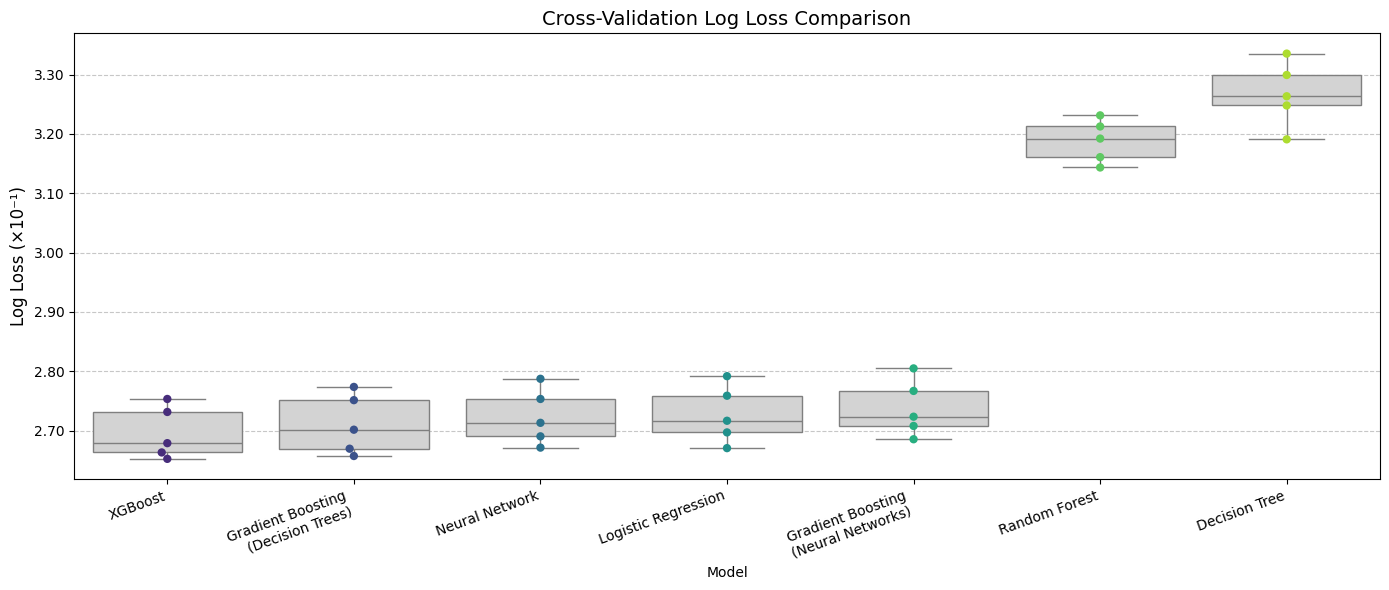

In [22]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Logistic Regression': logistic_log_loss_scores,
    'Decision Tree': dt_log_loss_scores,
    'Random Forest': rf_log_loss_scores,
    'Neural Network': mlp_log_loss_scores,
    "GB (Decision Trees)": gb_log_loss_scores,
    'XGBoost': xgb_log_loss_scores,
    'GB (Neural Networks)': nn_gb_log_loss_scores
})

melted_df = results_df.melt(var_name='Model', value_name='Log Loss')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean Log Loss (best → worst)
model_order = (
    melted_df.groupby('Model')['Log Loss']
    .mean()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='Log Loss',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='Log Loss',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-1 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e1:.2f}'))
plt.ylabel('Log Loss (×10⁻¹)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation Log Loss Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

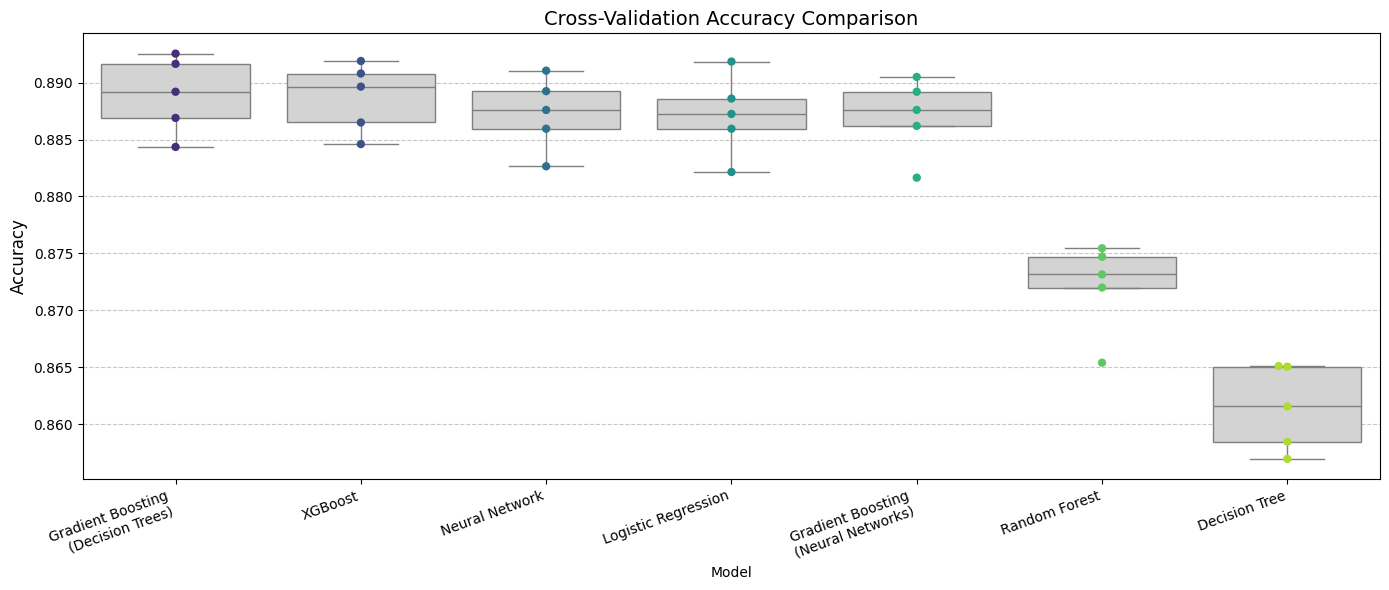

In [23]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Logistic Regression': logistic_accuracy_scores,
    'Decision Tree': dt_accuracy_scores,
    'Random Forest': rf_accuracy_scores,
    'Neural Network': mlp_accuracy_scores,
    "GB (Decision Trees)": gb_accuracy_scores,
    'XGBoost': xgb_accuracy_scores,
    'GB (Neural Networks)': nn_gb_accuracy_scores
})

melted_df = results_df.melt(var_name='Model', value_name='Accuracy')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean Accuracy (best [max] → worst [min])
model_order = (
    melted_df.groupby('Model')['Accuracy']
    .mean()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='Accuracy',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='Accuracy',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis - No scaling
plt.ylabel('Accuracy', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation Accuracy Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### VISUALIZATION (BY MEDIAN)

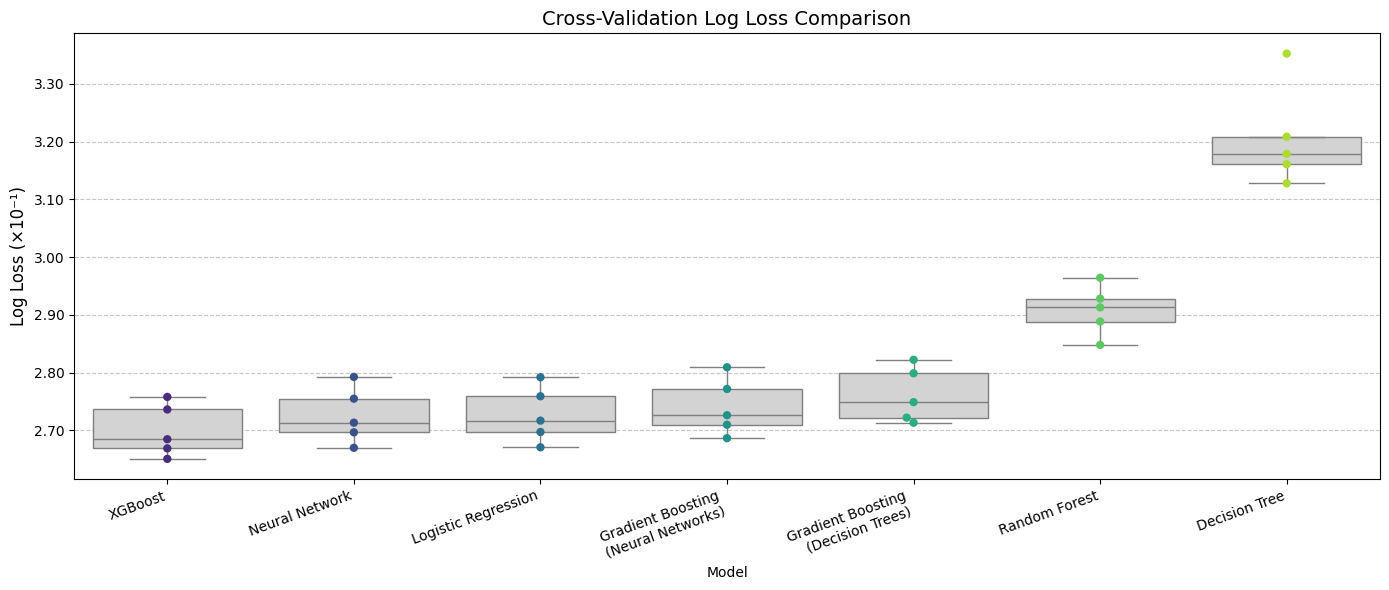

In [ ]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Logistic Regression': logistic_log_loss_scores,
    'Decision Tree': dt_log_loss_scores,
    'Random Forest': rf_log_loss_scores,
    'Neural Network': mlp_log_loss_scores,
    "GB (Decision Trees)": gb_log_loss_scores,
    'XGBoost': xgb_log_loss_scores,
    'GB (Neural Networks)': nn_gb_log_loss_scores
})

melted_df = results_df.melt(var_name='Model', value_name='Log Loss')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean Log Loss (best → worst)
model_order = (
    melted_df.groupby('Model')['Log Loss']
    .median()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='Log Loss',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='Log Loss',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-1 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e1:.2f}'))
plt.ylabel('Log Loss (×10⁻¹)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation Log Loss Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

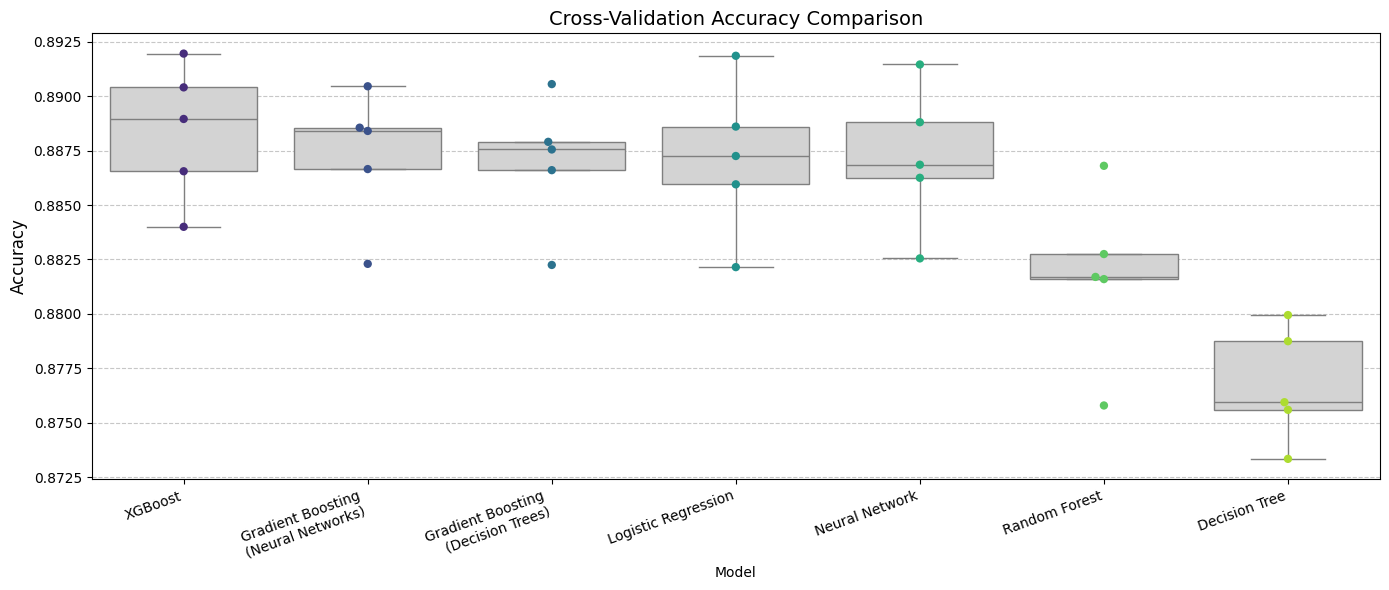

In [ ]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Logistic Regression': logistic_accuracy_scores,
    'Decision Tree': dt_accuracy_scores,
    'Random Forest': rf_accuracy_scores,
    'Neural Network': mlp_accuracy_scores,
    "GB (Decision Trees)": gb_accuracy_scores,
    'XGBoost': xgb_accuracy_scores,
    'GB (Neural Networks)': nn_gb_accuracy_scores
})

melted_df = results_df.melt(var_name='Model', value_name='Accuracy')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean Accuracy (best [max] → worst [min])
model_order = (
    melted_df.groupby('Model')['Accuracy']
    .median()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='Accuracy',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='Accuracy',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis - No scaling
plt.ylabel('Accuracy', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation Accuracy Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()